# Smart Agriculture Yield Prediction using Machine Learning

This project predicts crop yield using various machine learning algorithms
such as Linear Regression, Decision Tree, Random Forest, and KNN.

It also applies K-Means clustering to identify agricultural zones
based on environmental conditions.

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import mean_squared_error, r2_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.cluster import KMeans

## Dataset Loading and Exploration

The dataset contains agricultural features such as rainfall, temperature,
soil type, and crop type. The target variable is yield in tons per hectare.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (3).zip to archive (3).zip


In [ ]:
#unzip the file
import zipfile
import os

zip_path = "archive (3).zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted to:", extract_path)

Files extracted to: /content/dataset


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r /content/dataset /content/drive/MyDrive/

In [8]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/dataset/crop_yield.csv')
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


## Data Preprocessing

- Missing values handled
- Categorical variables encoded using LabelEncoder
- Boolean values converted to numeric
- Features scaled using StandardScaler

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
df_enc = df.copy()

# Convert boolean columns (true/false strings) to 0/1
df_enc["Fertilizer_Used"] = df_enc["Fertilizer_Used"].map({True: 1, False: 0, "true": 1, "false": 0})
df_enc["Irrigation_Used"] = df_enc["Irrigation_Used"].map({True: 1, False: 0, "true": 1, "false": 0})

# Encode categorical columns
le = LabelEncoder()
for col in ["Region", "Soil_Type", "Crop", "Weather_Condition"]:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

# Drop index column if it exists
if "index" in df_enc.columns:
    df_enc.drop("index", axis=1, inplace=True)

# Feature / Target split
X = df_enc.drop("Yield_tons_per_hectare", axis=1)
y = df_enc["Yield_tons_per_hectare"]

print("Features:", list(X.columns))
print("Target: Yield_tons_per_hectare")

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

Features: ['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition', 'Days_to_Harvest']
Target: Yield_tons_per_hectare

Train: 800000 | Test: 200000


## Feature Selection

Input Features: Environmental and agricultural parameters  
Target: Yield_tons_per_hectare

In [ ]:
from sklearn.metrics import mean_absolute_error


In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=6, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=42),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    predictions[name] = y_pred

    results[name] = {
        "R2": r2_score(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
    }

    print(f"{name} → R²: {results[name]['R2']:.4f} | "
          f"MSE: {results[name]['MSE']:.4f} | "
          f"MAE: {results[name]['MAE']:.4f}")

# Model comparison table
results_df = pd.DataFrame(results).T.sort_values("R2", ascending=False)

print("\n── Model Comparison ──")
print(results_df.round(4))

Linear Regression → R²: 0.9130 | MSE: 0.2508 | MAE: 0.3996
Decision Tree → R²: 0.9035 | MSE: 0.2783 | MAE: 0.4208
Random Forest → R²: 0.9065 | MSE: 0.2694 | MAE: 0.4143
KNN Regressor → R²: 0.8874 | MSE: 0.3246 | MAE: 0.4545

── Model Comparison ──
                       R2     MSE     MAE
Linear Regression  0.9130  0.2508  0.3996
Random Forest      0.9065  0.2694  0.4143
Decision Tree      0.9035  0.2783  0.4208
KNN Regressor      0.8874  0.3246  0.4545


In [ ]:
# Use meaningful numeric columns for clustering
cluster_features = df[["Rainfall_mm", "Temperature_Celsius", "Days_to_Harvest", "Yield_tons_per_hectare"]]

cs = StandardScaler()
cluster_scaled = cs.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(cluster_scaled)

summary = df.groupby("Cluster")[
    ["Rainfall_mm", "Temperature_Celsius", "Days_to_Harvest", "Yield_tons_per_hectare"]
].mean().round(2)
print("── Cluster Summary ──")
print(summary)

# Auto-label clusters by yield
low  = summary["Yield_tons_per_hectare"].idxmin()
high = summary["Yield_tons_per_hectare"].idxmax()
mid  = [c for c in range(3) if c not in [low, high]][0]

label_map = {
    low:  "Low Productivity Zone",
    high: "High Productivity Zone",
    mid:  "Moderate Conditions"
}
df["Cluster_Label"] = df["Cluster"].map(label_map)
print("\n", df["Cluster_Label"].value_counts())

── Cluster Summary ──
         Rainfall_mm  Temperature_Celsius  Days_to_Harvest  \
Cluster                                                      
0             301.41                27.37           104.62   
1             727.90                34.01           104.42   
2             730.45                20.94           104.39   

         Yield_tons_per_hectare  
Cluster                          
0                          3.15  
1                          5.89  
2                          5.57  

 Cluster_Label
Low Productivity Zone     418875
High Productivity Zone    296068
Moderate Conditions       285057
Name: count, dtype: int64


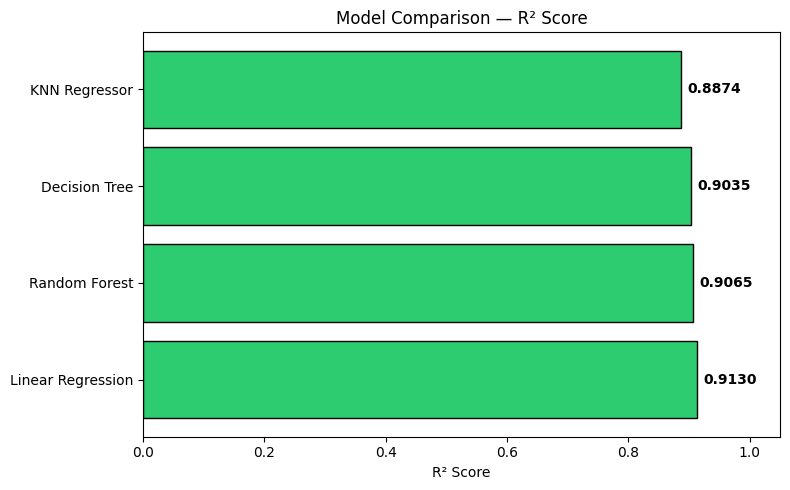

In [ ]:
plt.figure(figsize=(8, 5))
colors = ["#2ecc71" if r > 0.85 else "#f39c12" if r > 0.7 else "#e74c3c"
          for r in results_df["R2"]]
plt.barh(results_df.index, results_df["R2"], color=colors, edgecolor="black")
plt.xlabel("R² Score")
plt.title("Model Comparison — R² Score")
plt.xlim(0, 1.05)
for i, v in enumerate(results_df["R2"]):
    plt.text(v + 0.01, i, f"{v:.4f}", va="center", fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

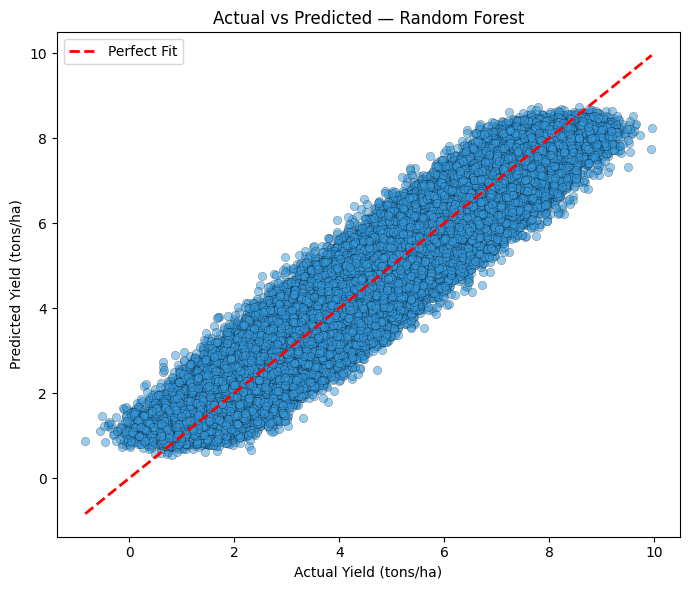

In [ ]:
y_pred_rf = predictions["Random Forest"]
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color="#3498db", edgecolors="black", linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2, label="Perfect Fit")
plt.xlabel("Actual Yield (tons/ha)")
plt.ylabel("Predicted Yield (tons/ha)")
plt.title("Actual vs Predicted — Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150)
plt.show()

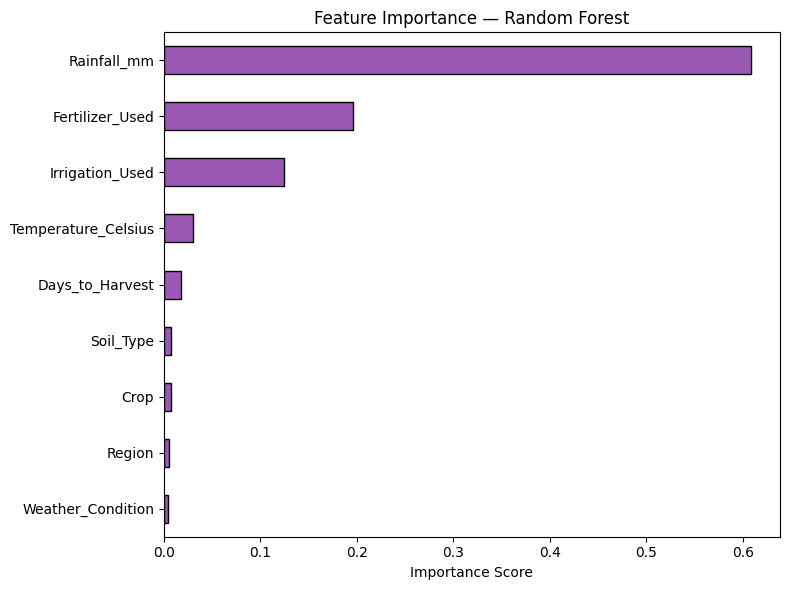

In [ ]:
rf_model = models["Random Forest"]
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color="#9b59b6", edgecolor="black")
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

/tmp/ipykernel_8046/131723530.py:16: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_8046/131723530.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("clustering.png", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


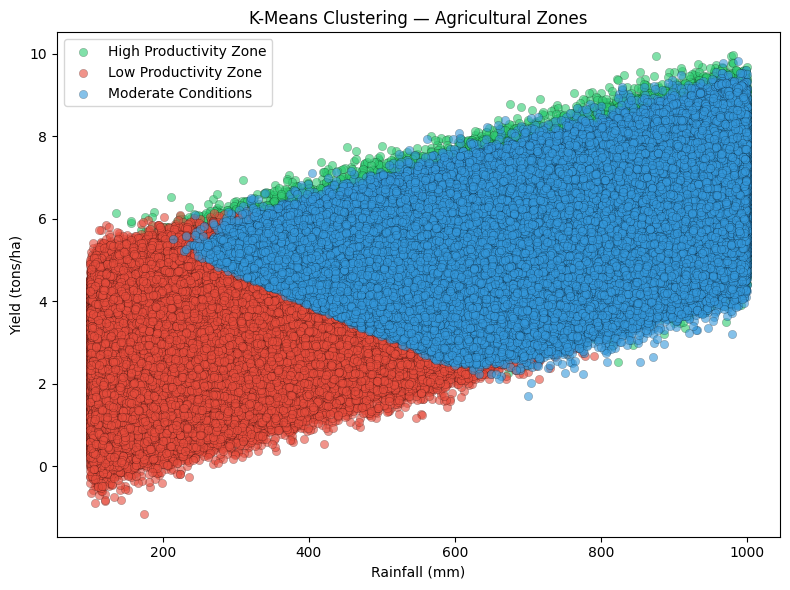

In [ ]:
color_map = {
    "Low Productivity Zone":  "#e74c3c",
    "High Productivity Zone": "#2ecc71",
    "Moderate Conditions":    "#3498db"
}

plt.figure(figsize=(8, 6))
for label, grp in df.groupby("Cluster_Label"):
    plt.scatter(grp["Rainfall_mm"], grp["Yield_tons_per_hectare"],
                label=label, alpha=0.6, color=color_map[label],
                edgecolors="black", linewidths=0.2)
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tons/ha)")
plt.title("K-Means Clustering — Agricultural Zones")
plt.legend()
plt.tight_layout()
plt.savefig("clustering.png", dpi=150)
plt.show()